# Práctica 0: Análisis Exploratorio de Datos de Videojuegos
**Asignatura:** Aprendizaje Automático y Minería de Datos  
**Grado en Desarrollo de Videojuegos**

---

## Objetivos de la Práctica
1. Familiarizarse con el entorno **Jupyter Notebook** e importar las librerías esenciales (`pandas`, `matplotlib`, `seaborn`).
2. Cargar y explorar un conjunto de datos real sobre videojuegos (`games.csv`).
3. Realizar tareas básicas de **limpieza de datos** (gestión de nulos, tipos de datos y listas de géneros).
4. Generar **visualizaciones estadísticas** (histogramas, gráficos de barras y diagramas de dispersión) para responder a preguntas de negocio sobre la industria.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Estilo visual limpio usando solo Matplotlib
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Librerías (Pandas y Matplotlib) cargadas correctamente.")

✅ Librerías (Pandas y Matplotlib) cargadas correctamente.


## Bloque 1: Carga y Exploración Inicial de Datos

Los datos se encuentran almacenados en la carpeta relativa `../data/raw/games.csv` (respecto a la carpeta `notebooks/`).

In [13]:
# Definición de la ruta relativa desde 'notebooks/' hasta 'data/raw/'
DATA_PATH = os.path.join("..", "data", "raw", "games.csv")

# Carga del archivo CSV asegurando la cabecera e índice correctos
df = pd.read_csv(DATA_PATH, index_col=0) # o index_col='AppID' si aplica

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("--- Primeras 5 filas del dataset ---")
df.head()

Dimensiones del dataset: 125855 filas y 39 columnas.

--- Primeras 5 filas del dataset ---


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [ ]:
# Inspección de los tipos de datos y valores nulos
df.info()

Conviene ejecutar esto para asegurarte del todo de cual es el nombre de las columnas.

In [ ]:
print(df_clean.columns)

## Bloque 2: Limpieza y Preparación de Datos (Data Wrangling)

Antes de analizar los géneros o precios, debemos:
1. Asegurarnos de que las columnas numéricas (`price`, `user_reviews` o `rating`) tengan el tipo correcto.
2. Formatear la columna de géneros (que habitualmente viene separada por comas, ej: `"Action, Indie, Strategy"`).

In [14]:
# Crear una copia de trabajo
df_clean = df.copy()

# 1. Tratamiento de Géneros ('Genres')
# Convertimos el texto "Action, Casual, Indie" en listas de Python
df_clean['genres_list'] = (
    df_clean['Genres']
    .fillna("Desconocido")
    .astype(str)
    .apply(lambda x: [g.strip() for g in x.split(',')])
)

# 2. Tratamiento de Precios ('Price')
# Nos aseguramos de que sea un valor numérico continuo
df_clean['price_clean'] = pd.to_numeric(df_clean['Price'], errors='coerce').fillna(0)

# 3. Calcular un porcentaje de reseñas positivas
# Creamos una métrica útil: % de valoraciones positivas respecto al total
import numpy as np

total_reviews = df_clean['Positive'] + df_clean['Negative']
df_clean['positivity_ratio'] = np.where(total_reviews > 0, (df_clean['Positive'] / total_reviews) * 100, np.nan)

print("✅ Columnas procesadas correctamente:")
df_clean[['Name', 'Price', 'genres_list', 'positivity_ratio']].head()

✅ Columnas procesadas correctamente:


,Name,Price,genres_list,positivity_ratio
2539430,"Aug 1, 2023",0,[Desconocido],NaN
496350,"Jul 29, 2016",65,[Adventure],98.823529
1034400,"May 6, 2019",0,[Casual],87.500000
3292190,"Oct 31, 2024",0,"[Casual, Indie, Simulation]",NaN
3631080,"Apr 24, 2025",0,"[Action, Early Access]",NaN


## Bloque 3: Estadística Descriptiva y Visualización (Data Mining)

### Pregunta 1: ¿Cuáles son los géneros más comunes/producidos?
Para responder a esto, desplegamos la lista de géneros para contar cuántos videojuegos pertenecen a cada uno de ellos.

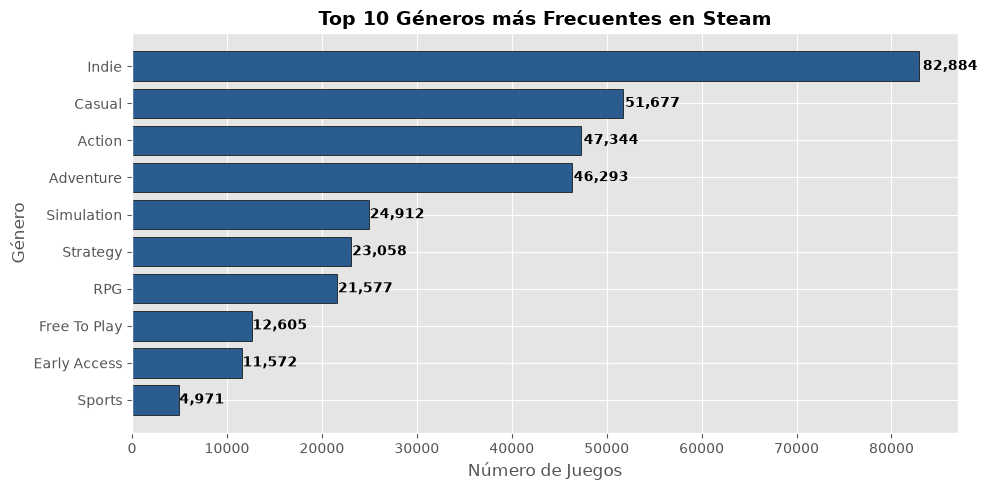

In [10]:
# Explotar la lista para contar cada género por separado
df_exploded = df_clean.explode('genres_list')

# Filtrar posibles valores vacíos o desconocidos y coger el Top 10
top_genres = (
    df_exploded[df_exploded['genres_list'] != "Desconocido"]['genres_list']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

# Visualización con Matplotlib
plt.figure(figsize=(10, 5))
bars = plt.barh(top_genres.index, top_genres.values, color='#2b5c8f', edgecolor='black')

plt.title("Top 10 Géneros más Frecuentes en Steam", fontsize=14, fontweight='bold')
plt.xlabel("Número de Juegos")
plt.ylabel("Género")

# Añadir el número exacto en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.005), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Pregunta 2: ¿Cómo se distribuyen los precios de los videojuegos?
Analizamos la distribución del precio excluyendo los juegos gratuitos (*Free-to-Play*) para ver el comportamiento del mercado de pago.

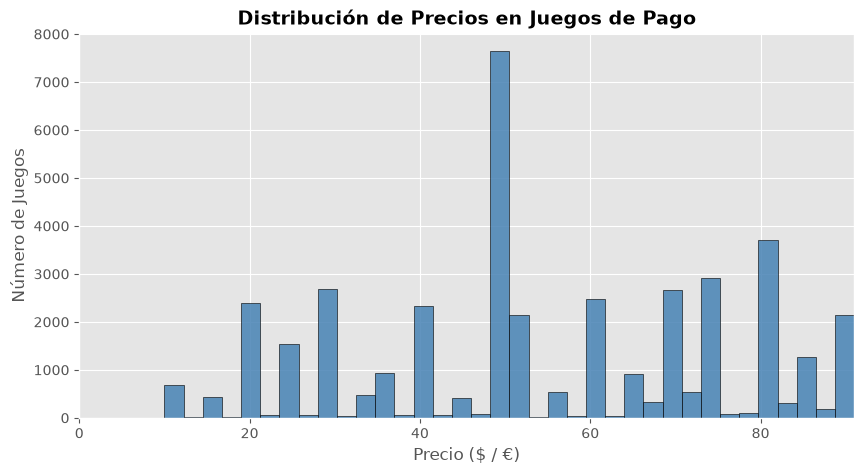

Precio medio (juegos de pago): 55.19
Mediana del precio: 51.00


In [11]:
# Filtrar juegos de pago (Price > 0)
de_pago = df_clean[df_clean['price_clean'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(de_pago['price_clean'], bins=40, color='#4682b4', edgecolor='black', alpha=0.85)

plt.title("Distribución de Precios en Juegos de Pago", fontsize=14, fontweight='bold')
plt.xlabel("Precio ($ / €)")
plt.ylabel("Número de Juegos")

# Recortamos el gráfico en el percentil 99 para evitar que un juego de 999$ desfigure el histograma
plt.xlim(0, de_pago['price_clean'].quantile(0.99))
plt.show()

print(f"Precio medio (juegos de pago): {de_pago['price_clean'].mean():.2f}")
print(f"Mediana del precio: {de_pago['price_clean'].median():.2f}")

### Pregunta 3: ¿El precio influye en las valoraciones o en el volumen de reseñas?
Analizamos la relación entre dos variables continuas mediante un diagrama de dispersión (*Scatter Plot*).

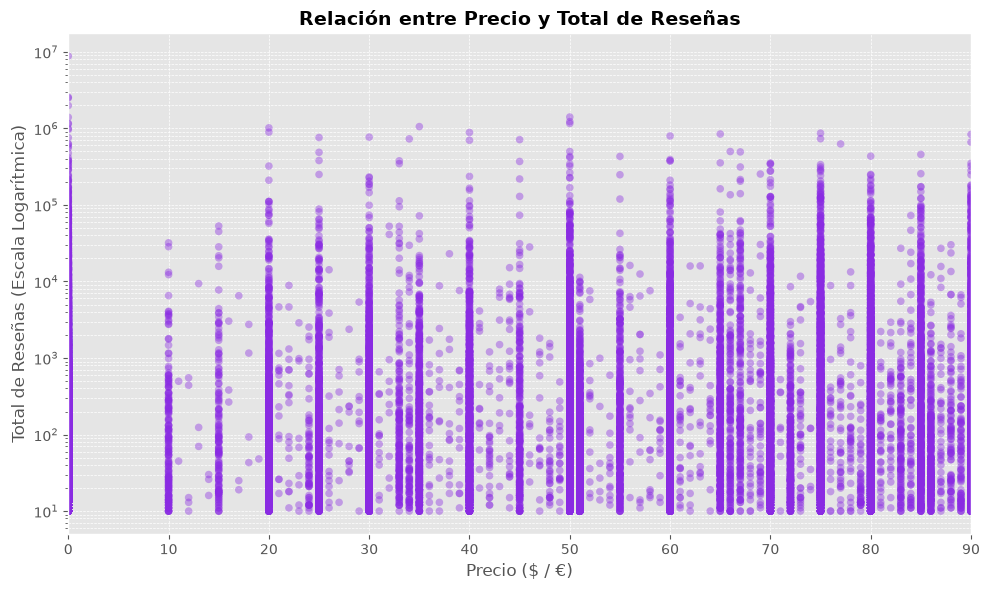

In [12]:
# Calcular total de valoraciones para el eje Y
df_clean['total_reviews'] = df_clean['Positive'] + df_clean['Negative']

# Filtrar juegos que tengan al menos 10 valoraciones para evitar ruido
df_con_reviews = df_clean[df_clean['total_reviews'] >= 10]

plt.figure(figsize=(10, 6))
plt.scatter(df_con_reviews['price_clean'], df_con_reviews['total_reviews'], 
            alpha=0.4, color='#8a2be2', edgecolors='none', s=30)

plt.title("Relación entre Precio y Total de Reseñas", fontsize=14, fontweight='bold')
plt.xlabel("Precio ($ / €)")
plt.ylabel("Total de Reseñas (Escala Logarítmica)")
plt.yscale('log') # Escala logarítmica fundamental en Steam por los superventas
plt.xlim(0, df_con_reviews['price_clean'].quantile(0.99))
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.tight_layout()
plt.show()

## Conclusiones de la Práctica 0
* Hemos estructurado el flujo de trabajo básico: **Lectura → Limpieza → Transformación → Visualización**.
* `pandas` nos permite manipular fácilmente listas dentro de tablas (`explode`, `apply`).
* La librería `seaborn` simplifica la creación de gráficos claros y descriptivos para presentar conclusiones sobre el mercado de videojuegos.